# Lecture 10 - Data Wrangling

In this lecture we will explore cyclist count data from Brisbane in 2021. The data was gathered from the Brisbane City Council's open data portal.

In [1]:
# standard imports for data processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Import the 'bike-ped-auto-counts-2021.csv' dataset. Ensure the Date column is imported in datetime format and is set as the index of the dataframe. Inspect the data to get a feel for the format.

In [2]:
# import and inspect data
auto_counts = pd.read_csv('Data/bike-ped-auto-counts-2021.csv', index_col='Date', parse_dates=True)
auto_counts

,"A001, Bicentennial Bikeway, Auchenflower _Pedestrian","A001, Bicentennial Bikeway, Auchenflower _Cyclist","A019, Bicentennial Bikeway, Milton _Pedestrian","A019, Bicentennial Bikeway, Milton _Cyclist","A002, Bishop Street, Kelvin Grove _Pedestrian","A002, Bishop Street, Kelvin Grove _Cyclist","A023, Botanic Gardens, City _Pedestrian","A023, Botanic Gardens, City _Cyclist","A003, Ekibin Park, Greenslopes _Pedestrian","A003, Ekibin Park, Greenslopes _Cyclist",...,"A028, Indooroopilly Riverwalk, Indooroopilly _Pedestrian","A028, Indooroopilly Riverwalk, Indooroopilly _Cyclist","A029, Lytton Road, East Brisbane _Cyclist","A200,_Cyclist City Link Cycleway (Edward St - Charlotte to Mary), City","A200,_Scooter City Link Cycleway (Edward St - Charlotte to Mary), City","A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City","A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City","A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City","A203,_Cyclist City Link Cycleway (Victoria Bridge), City","A203,_Scooter City Link Cycleway (Victoria Bridge), City"
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,1375.0,1718.0,1180.0,1780.0,1030,96,2955.0,1518.0,732,186.0,...,NaN,NaN,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,1668.0,2649.0,1445.0,2865.0,795,98,3267.0,2136.0,672,243.0,...,NaN,NaN,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,1939.0,3062.0,1251.0,3217.0,518,163,3172.0,2448.0,762,251.0,...,NaN,NaN,329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,2007.0,2587.0,1218.0,2780.0,469,147,2583.0,1792.0,843,215.0,...,NaN,NaN,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,1570.0,3474.0,1080.0,3648.0,389,134,1959.0,2163.0,636,179.0,...,NaN,NaN,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,NaN,NaN,1304.0,2211.0,421,103,2798.0,1457.0,389,215.0,...,851.0,752.0,202,NaN,NaN,158.0,201.0,292.0,215.0,749.0
2021-12-28,NaN,NaN,1478.0,1273.0,414,89,3390.0,1210.0,348,205.0,...,796.0,503.0,147,NaN,NaN,214.0,308.0,481.0,265.0,975.0
2021-12-29,NaN,NaN,1530.0,2596.0,499,118,3519.0,1945.0,407,310.0,...,771.0,971.0,328,NaN,NaN,226.0,347.0,464.0,269.0,1032.0


In [3]:
auto_counts.columns

Index(['A001, Bicentennial Bikeway, Auchenflower  _Pedestrian',
       'A001, Bicentennial Bikeway, Auchenflower  _Cyclist',
       'A019, Bicentennial Bikeway, Milton  _Pedestrian',
       'A019, Bicentennial Bikeway, Milton  _Cyclist',
       'A002, Bishop Street, Kelvin Grove  _Pedestrian',
       'A002, Bishop Street, Kelvin Grove  _Cyclist',
       'A023, Botanic Gardens, City  _Pedestrian',
       'A023, Botanic Gardens, City  _Cyclist',
       'A003, Ekibin Park, Greenslopes  _Pedestrian',
       'A003, Ekibin Park, Greenslopes  _Cyclist',
       'A004, Eleanor Schonell Br Cyclists, St Lucia  _Cyclist',
       'A004, Eleanor Schonell Br Pedestrians, St Lucia  _Pedestrian',
       'A005, Go Between Br Cyclists, South Brisbane   _Cyclist',
       'A005, Go Between Br Pedestrians, South Brisbane  _Pedestrian',
       'A006, Granville St Bridge, Herston  _Pedestrian',
       'A006, Granville St Bridge, Herston  _Cyclist',
       'A020, Gympie Rd (Marchant Park), Chermside  _Pedestri

## Updating Data
There are lots of autocount locations in the data, so let's focus our analysis on a select few. Select the Maritime Museum and Annerley Rd locations. Rename the columns to ones that are more convenient to use. Add day and month columns to the data.

In [4]:
# updating data (adding, removing and renaming columns)
# selecting columns
auto_counts = auto_counts[['A025, Maritime Museum, South Brisbane  _Pedestrian',
                           'A025, Maritime Museum, South Brisbane  _Cyclist',
                           'A026, Annerley Rd, South Brisbane  _Cyclist']]
auto_counts

,"A025, Maritime Museum, South Brisbane _Pedestrian","A025, Maritime Museum, South Brisbane _Cyclist","A026, Annerley Rd, South Brisbane _Cyclist"
Date,,,
2021-01-01,5710.0,1738.0,265
2021-01-02,6485.0,2538.0,462
2021-01-03,6525.0,2974.0,479
2021-01-04,4720.0,2865.0,538
2021-01-05,4690.0,3353.0,637
...,...,...,...
2021-12-27,4644.0,1970.0,351
2021-12-28,3073.0,910.0,224
2021-12-29,3875.0,1311.0,397


In [5]:
# renaming columns
auto_counts = auto_counts.rename(columns={'A025, Maritime Museum, South Brisbane  _Pedestrian': 'Pedestrian',
                                           'A025, Maritime Museum, South Brisbane  _Cyclist': 'Cyclist',
                                           'A026, Annerley Rd, South Brisbane  _Cyclist': 'Cyclist_nearby'})
auto_counts

,Pedestrian,Cyclist,Cyclist_nearby
Date,,,
2021-01-01,5710.0,1738.0,265
2021-01-02,6485.0,2538.0,462
2021-01-03,6525.0,2974.0,479
2021-01-04,4720.0,2865.0,538
2021-01-05,4690.0,3353.0,637
...,...,...,...
2021-12-27,4644.0,1970.0,351
2021-12-28,3073.0,910.0,224
2021-12-29,3875.0,1311.0,397


In [6]:
# adding columns
auto_counts['Day'] = auto_counts.index.day_name()
auto_counts['Month'] = auto_counts.index.month
auto_counts

,Pedestrian,Cyclist,Cyclist_nearby,Day,Month
Date,,,,,
2021-01-01,5710.0,1738.0,265,Friday,1
2021-01-02,6485.0,2538.0,462,Saturday,1
2021-01-03,6525.0,2974.0,479,Sunday,1
2021-01-04,4720.0,2865.0,538,Monday,1
2021-01-05,4690.0,3353.0,637,Tuesday,1
...,...,...,...,...,...
2021-12-27,4644.0,1970.0,351,Monday,12
2021-12-28,3073.0,910.0,224,Tuesday,12
2021-12-29,3875.0,1311.0,397,Wednesday,12


## Cleaning Data
Now clean the data. This typically requires the following:
* Check whether data types are appropriate
* Check for missing values
* Inspect the data for incorrect values or outliers
* Do format checks where appropriate

In [7]:
# data types
auto_counts.dtypes

Pedestrian        float64
Cyclist           float64
Cyclist_nearby      int64
Day                object
Month               int32
dtype: object

In [8]:
auto_counts.index

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10',
               ...
               '2021-12-22', '2021-12-23', '2021-12-24', '2021-12-25',
               '2021-12-26', '2021-12-27', '2021-12-28', '2021-12-29',
               '2021-12-30', '2021-12-31'],
              dtype='datetime64[ns]', name='Date', length=365, freq=None)

In [9]:
# convert month to ordered categorical
# define category list in order
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# convert column to an ordered categorical
auto_counts['Day'] = pd.Categorical(auto_counts.Day, categories=day_names, ordered=True)
auto_counts.dtypes

# intersting that first two columns are floats - should be integers

Pedestrian         float64
Cyclist            float64
Cyclist_nearby       int64
Day               category
Month                int32
dtype: object

In [10]:
# missing values
auto_counts.isna().sum()

Pedestrian        151
Cyclist           151
Cyclist_nearby      0
Day                 0
Month               0
dtype: int64

In [11]:
# what to do with missing values?
# can remove, replace or keep - context matters!

In [12]:
# aggregates still work with missing values
auto_counts.Pedestrian.mean()

np.float64(4363.154205607477)

In [13]:
# total number - missing values affects our approach
auto_counts.Pedestrian.mean() * 365

np.float64(1592551.285046729)

<Axes: xlabel='Date'>

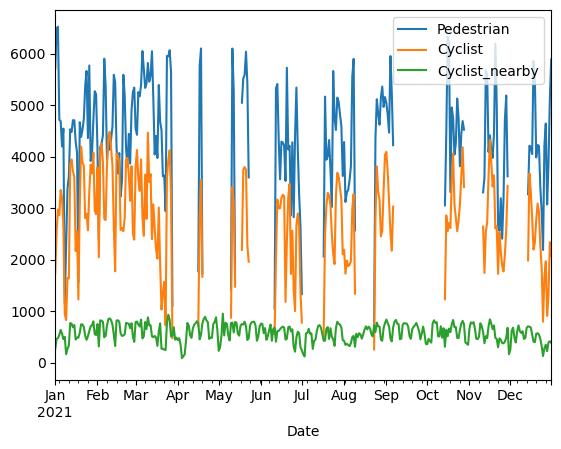

In [14]:
# plots still work with missing values
count_cols = ['Pedestrian', 'Cyclist', 'Cyclist_nearby']
auto_counts.plot(y=count_cols)

array([[<Axes: xlabel='Pedestrian', ylabel='Pedestrian'>,
        <Axes: xlabel='Cyclist', ylabel='Pedestrian'>,
        <Axes: xlabel='Cyclist_nearby', ylabel='Pedestrian'>],
       [<Axes: xlabel='Pedestrian', ylabel='Cyclist'>,
        <Axes: xlabel='Cyclist', ylabel='Cyclist'>,
        <Axes: xlabel='Cyclist_nearby', ylabel='Cyclist'>],
       [<Axes: xlabel='Pedestrian', ylabel='Cyclist_nearby'>,
        <Axes: xlabel='Cyclist', ylabel='Cyclist_nearby'>,
        <Axes: xlabel='Cyclist_nearby', ylabel='Cyclist_nearby'>]],
      dtype=object)

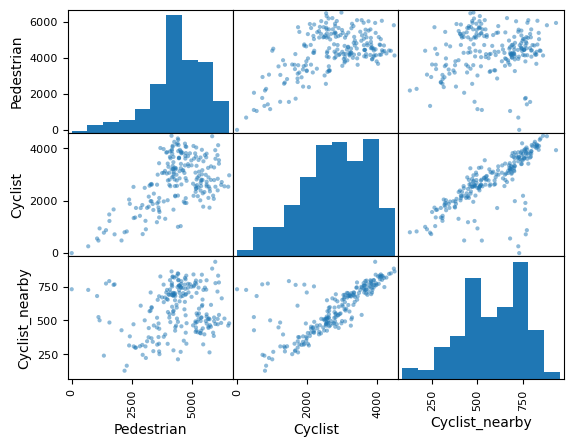

In [15]:
# inspecting outliers and incorrect values
pd.plotting.scatter_matrix(auto_counts[count_cols])

In [16]:
# there are some outliers in this data - strong linear relationship between cyclist and cyclist_nearby
# but have 10-20 points well off the trend line.

# what to do? investigate to see if the values are wrong - often requires domain knowledge. 
# Don't just default to removing immediately.

In [20]:
# format checking
# counts need to be non-negative and integers

counts = auto_counts[count_cols]
# invalid if not missing and negative or not integer
is_invalid = (~counts.isna()) & ((counts < 0) | (counts % 1 != 0))
is_invalid.sum()

Pedestrian        0
Cyclist           0
Cyclist_nearby    0
dtype: int64

<Axes: >

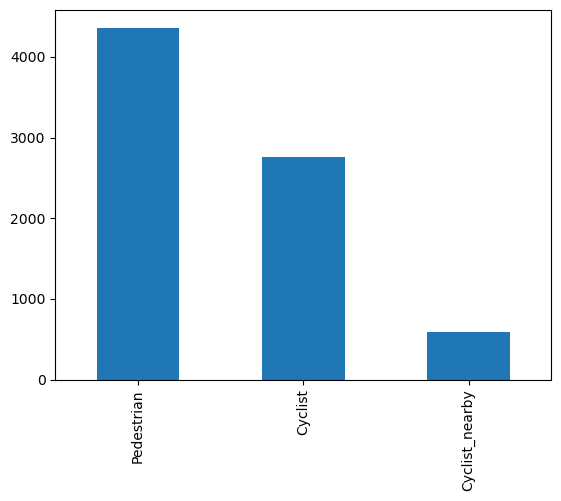

In [23]:
avg_counts = counts.mean()
avg_counts.plot(kind='bar')

<Axes: >

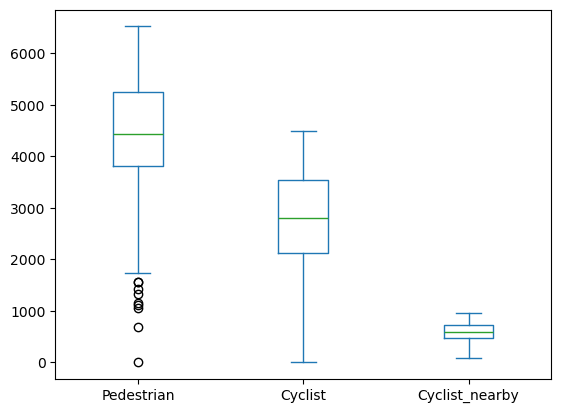

In [26]:
counts.plot(kind='box')

## Joining Data
Suppose we want to investigate the effect on climate (eg. temperatures, rainfall) on daily cyclist and pedestrian counts. We could import daily weather data 'BrisbaneDailyWeather.csv' which is gathered from the Bureau of Meteorology. We could then join the datasets together. We need to have an index or column (or set of columns) in common between the datasets in order to join them.

Different types of joins / merge
* inner (default)
* left (use keys from left frame)
* right (use keys from right frame)
* outer (use keys from both frames)

Join is used to join by index, whereas merge is used to join by columns.

Can use left_on and right_on arguments if the joining columns have different names.

In [18]:
# import the 'BrisbaneDailyWeather.csv' file, converting the Data column to datetime format and setting it as the index.

In [19]:
# join the datasets together, and then determine how climate effects the counts